1.Import necessary packages

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats import weightstats as stests
sns.set(color_codes=True)


2.Load the file

In [3]:
ins = pd.read_csv("/Users/magadi.sudhindra/AIML/insurance.csv")

In [13]:
ins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


3a.Shape of the data

In [4]:
ins.shape

(1338, 7)

 3b.Data type of each attribute

In [5]:
ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
age         1338 non-null int64
sex         1338 non-null object
bmi         1338 non-null float64
children    1338 non-null int64
smoker      1338 non-null object
region      1338 non-null object
charges     1338 non-null float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


3c .Checking the presence of missing values


In [6]:
ins.notnull() 

,age,sex,bmi,children,smoker,region,charges
0,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True
5,True,True,True,True,True,True,True
6,True,True,True,True,True,True,True
7,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True
9,True,True,True,True,True,True,True


3d. 5 point summary of numerical attributes

In [12]:
ins.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


  3e : Distrubution of BMI,Age,Charges

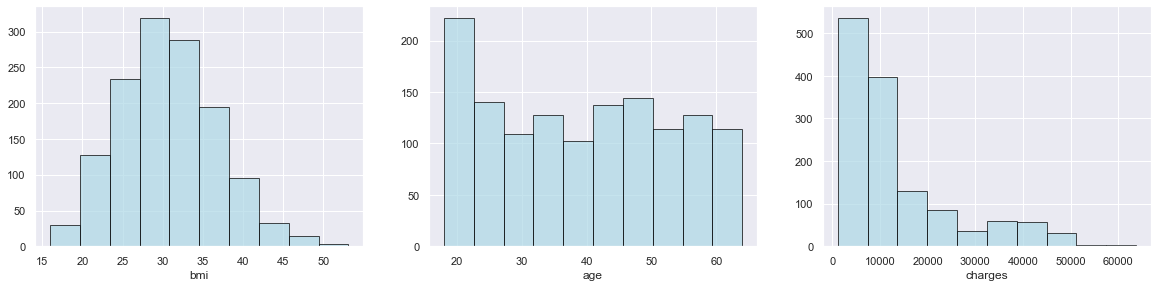

In [13]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
plt.hist(ins.bmi, color='lightblue', edgecolor = 'black', alpha = 0.7)
plt.xlabel('bmi')

plt.subplot(3,3,2)
plt.hist(ins.age, color='lightblue', edgecolor = 'black', alpha = 0.7)
plt.xlabel('age')

plt.subplot(3,3,3)
plt.hist(ins.charges, color='lightblue', edgecolor = 'black', alpha = 0.7)
plt.xlabel('charges')

plt.show()



3f.Measure of skewness of ‘bmi’, ‘age’ and ‘charges’
columns

In [14]:
Skewness = pd.DataFrame({'Skewness' : [stats.skew(ins.bmi),stats.skew(ins.age),stats.skew(ins.charges)]},
                        index=['bmi','age','charges'])  
print(Skewness)

         Skewness
bmi      0.283729
age      0.055610
charges  1.514180


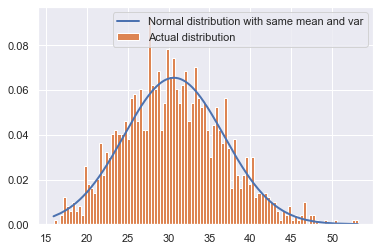

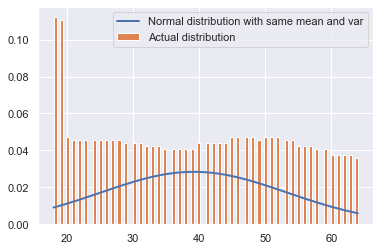

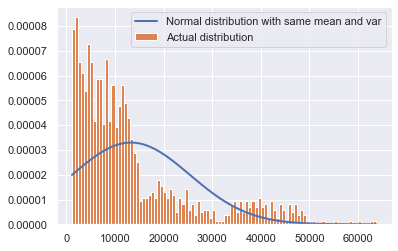

In [15]:


h = np.asarray(ins['bmi'])
h = sorted(h)
 
#use the scipy stats module to fit a normal distirbution with same mean and standard deviation
fit = stats.norm.pdf(h, np.mean(h), np.std(h)) 
 
#plot both series on the histogram
plt.plot(h,fit,'-',linewidth = 2,label="Normal distribution with same mean and var")
plt.hist(h,density=True,bins = 100,label="Actual distribution")      
plt.legend()
plt.show()

h = np.asarray(ins['age'])
h = sorted(h)
 
#use the scipy stats module to fit a normal distirbution with same mean and standard deviation
fit = stats.norm.pdf(h, np.mean(h), np.std(h)) 
 
#plot both series on the histogram
plt.plot(h,fit,'-',linewidth = 2,label="Normal distribution with same mean and var")
plt.hist(h,density=True,bins = 100,label="Actual distribution")      
plt.legend()
plt.show()

h = np.asarray(ins['charges'])
h = sorted(h)
 
#use the scipy stats module to fit a normal distirbution with same mean and standard deviation
fit = stats.norm.pdf(h, np.mean(h), np.std(h)) 
 
#plot both series on the histogram
plt.plot(h,fit,'-',linewidth = 2,label="Normal distribution with same mean and var")
plt.hist(h,density=True,bins = 100,label="Actual distribution")      
plt.legend()
plt.show()

3g.Checking the presence of outliers in ‘bmi’, ‘age’ and
‘charges columns

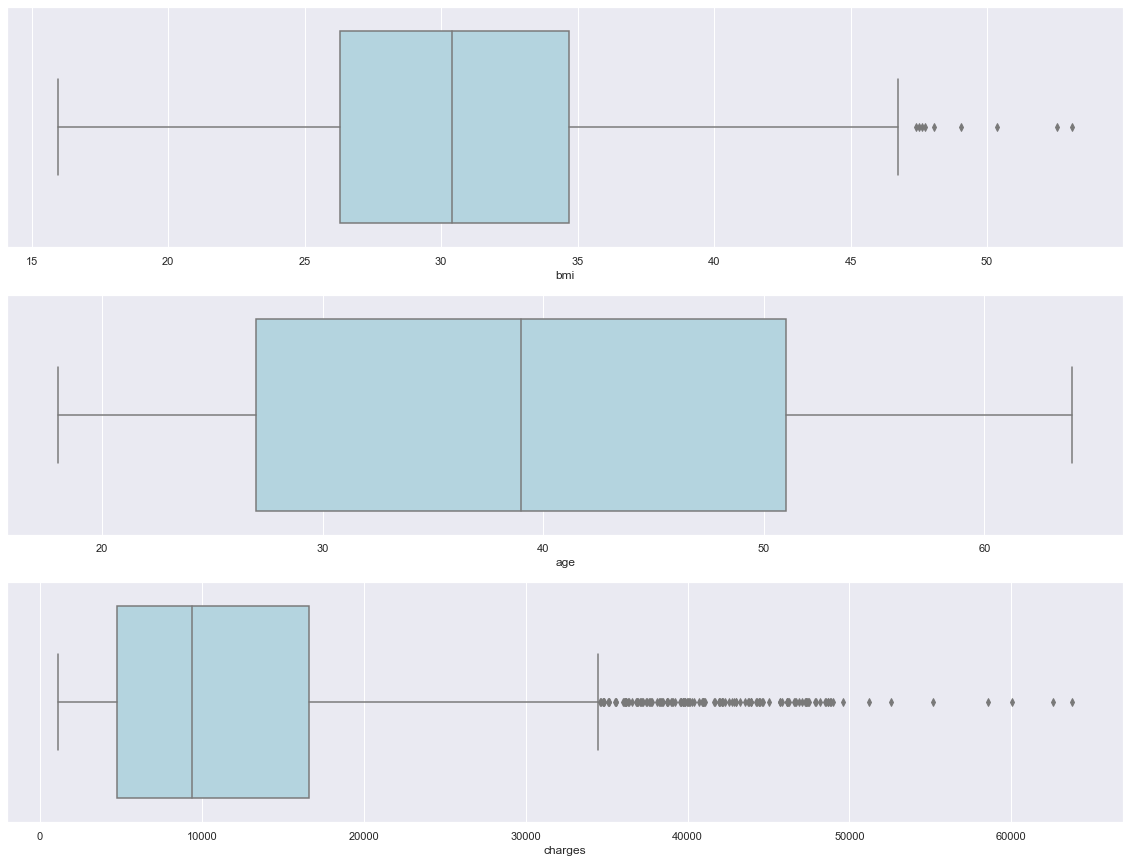

In [16]:



plt.figure(figsize= (20,15))
plt.subplot(3,1,1)
sns.boxplot(x= ins.bmi, color='lightblue')

plt.subplot(3,1,2)
sns.boxplot(x= ins.age, color='lightblue')

plt.subplot(3,1,3)
sns.boxplot(x= ins.charges, color='lightblue')

plt.show()

3h.Distribution of categorical columns (include
children)

Text(0.5, 1.0, 'Smoker distribution')

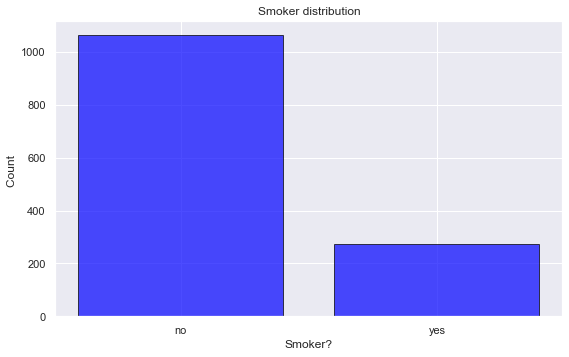

In [17]:
plt.figure(figsize=(20,25))


x = ins.smoker.value_counts().index    #Values for x-axis
y = [ins['smoker'].value_counts()[i] for i in x]   # Count of each class on y-axis

plt.subplot(4,2,1)
plt.bar(x,y, align='center',color = 'blue',edgecolor = 'black',alpha = 0.7)  #plot a bar chart
plt.xlabel('Smoker?')
plt.ylabel('Count ')
plt.title('Smoker distribution')

Text(0.5, 1.0, 'Sex distribution')

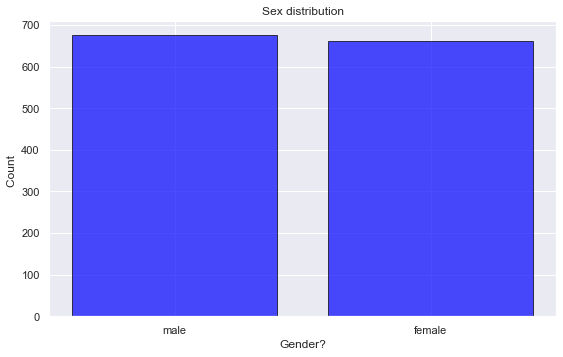

In [18]:
plt.figure(figsize=(20,25))


x = ins.sex.value_counts().index    #Values for x-axis
y = [ins['sex'].value_counts()[i] for i in x]   # Count of each class on y-axis

plt.subplot(4,2,1)
plt.bar(x,y, align='center',color = 'blue',edgecolor = 'black',alpha = 0.7)  #plot a bar chart
plt.xlabel('Gender?')
plt.ylabel('Count ')
plt.title('Sex distribution')

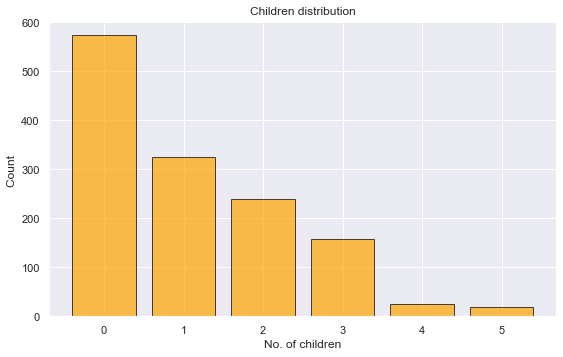

In [73]:
plt.figure(figsize=(20,25))


x3 = ins.children.value_counts().index    #Values for x-axis
y3 = [ins['children'].value_counts()[l] for l in x3]   # Count of each class on y-axis

plt.subplot(4,2,4)
plt.bar(x3,y3, align='center',color = 'orange',edgecolor = 'black',alpha = 0.7)  #plot a bar chart
plt.xlabel('No. of children')
plt.ylabel('Count ')
plt.title("Children distribution")

plt.show()

Text(0.5, 1.0, "Regions' distribution")

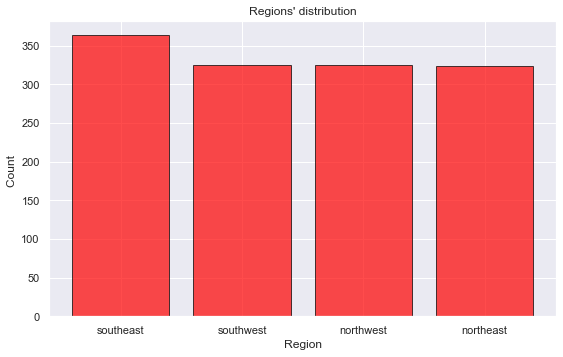

In [77]:
plt.figure(figsize=(20,25))
plt.subplot(4,2,3)

x2 = ins.region.value_counts().index    #Values for x-axis
y2 = [ins['region'].value_counts()[l] for l in x2]   # Count of each class on y-axis

plt.bar(x2,y2, align='center',color = 'red',edgecolor = 'black',alpha = 0.7)  #plot a bar chart
plt.xlabel('Region')
plt.ylabel('Count ')
plt.title("Regions' distribution")

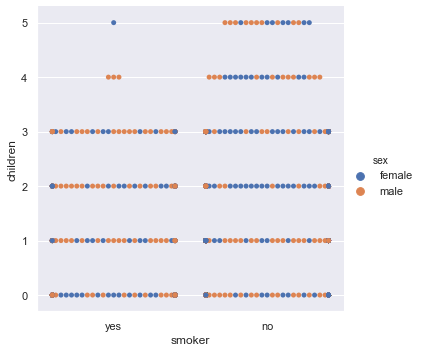

In [56]:
sns.catplot(x="smoker", y="children", kind="swarm",hue="sex", data=ins);

3i.Pairplotthatincludesallthecolumnsofthedata
frame

In [72]:
import seaborn as sns; sns.set(style="ticks", color_codes=True)

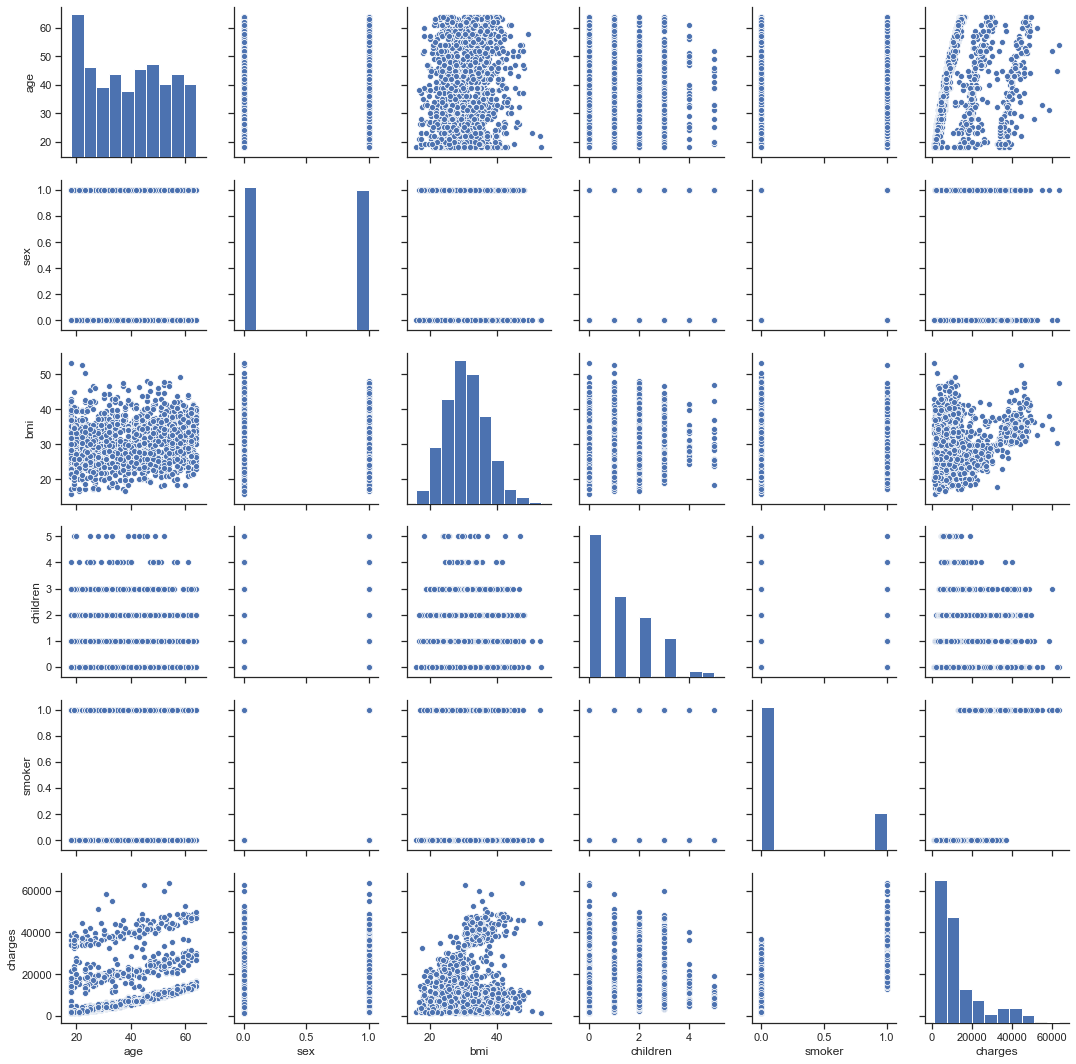

In [89]:
sns.pairplot(new2insdata)

4a .Do charges of people who smoke differ significantly from the people who don't?

In [78]:
ins.smoker.value_counts()

no     1064
yes     274
Name: smoker, dtype: int64

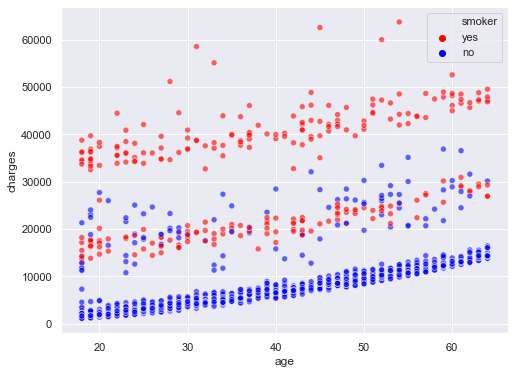

In [84]:
plt.figure(figsize=(8,6))
sns.scatterplot(ins.age, ins.charges,hue=ins.smoker,palette= ['red','blue'] ,alpha=0.6)
plt.show()

Difference between charges of smokers and charges of non-smokers is apparent

In [11]:
Ho = "Charges of smoker and non-smoker are same"   #null hypo
Ha = "Charges of smoker and non-smoker are not the same"   #  Alternate Hypothesis

x = np.array(ins[ins.smoker == 'yes'].charges)  # charge for smokers
y = np.array(ins[ins.smoker == 'no'].charges) # non smokers


#t, p_value  = stats.ttest_ind(x,y, axis = 0)  #Performing an Independent t-test




if p_value < 0.05:  # Setting our significance level at 5%
    print(f'{Ha} as the p_value ({p_value}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value}) > 0.05')

274
1064
Charges of smoker and non-smoker are not the same as the p_value (8.271435842177219e-283) < 0.05


In [ ]:
Ho = "Charges of smoker and non-smoker are same"   #null hypo
Ha = "Charges of smoker and non-smoker are not the same"   #  Alternate Hypothesis

x = np.array(ins[ins.smoker == 'yes'].charges)  # charge for smokers
y = np.array(ins[ins.smoker == 'no'].charges) # non smokers

t, p_value  = stats.ttest_ind(x,y, axis = 0)  #Performing an Independent t-test

if p_value < 0.05:  # Setting our significance level at 5%
    print(f'{Ha} as the p_value ({p_value}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value}) > 0.05')

4b . Does bmi of males differ significantly from that of females?

In [87]:
ins.sex.value_counts()

male      676
female    662
Name: sex, dtype: int64

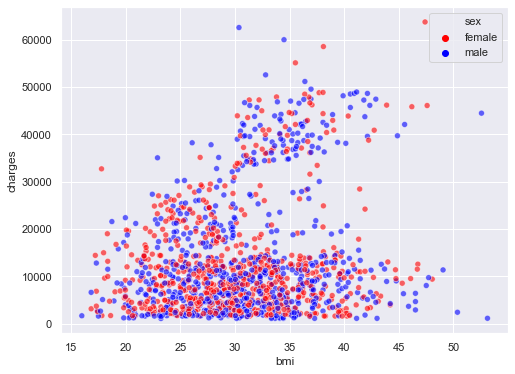

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(ins.bmi, ins.charges,hue=ins.sex,palette= ['red','blue'] ,alpha=0.6)
plt.show()

In [12]:
Ho = "BMI  of males and females are same"   #null hypo
Ha = "BMI of males and females are not the same"   #  Alternate Hypothesis

x = np.array(ins[ins.sex == 'male'].bmi)  # bmi of males
y = np.array(ins[ins.sex == 'female'].bmi) # bmi of females
t, p_value  = stats.ttest_ind(x,y, axis = 0)  #Performing an Independent t-test


if p_value < 0.05:  # Setting our significance level at 5%
    print(f'{Ha} as the p_value ({p_value}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value}) > 0.05')

BMI  of males and females are same as the p_value (0.08997637178984932) > 0.05


Is the proportion of smokers significantly different in different genders?

In [9]:
# Chi_square test 
Ho = "Gender has no effect on smoking habits"   # Stating the Null Hypothesis
Ha = "Gender has an effect on smoking habits"   # Stating the Alternate Hypothesis

crosstab = pd.crosstab(ins['sex'],ins['smoker'])  # Contingency table of sex and smoker attributes

chi, p_value, dof, expected =  stats.chi2_contingency(crosstab)

if p_value < 0.05:  # Setting our significance level at 5%
    print(f'{Ha} as the p_value ({p_value.round(3)}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value.round(3)}) > 0.05')
crosstab

Gender has an effect on smoking habits as the p_value (0.007) < 0.05


smoker,no,yes
sex,,
female,547,115
male,517,159


Is the distribution of bmi across women with no children, one child and two children, the same ?

In [13]:
import copy 

# Annova as multiple variables arte there
Ho = "Number of childrfen has no affect on BMI" 
Ha = "Number of childrfen has  affect on BMI"   # Stating the Alternate Hypothesis

female_df = copy.deepcopy(ins[ins['sex'] == 'female'])

zero = female_df[female_df.children == 0]['bmi']
one = female_df[female_df.children == 1]['bmi']
two = female_df[female_df.children == 2]['bmi']


f_stat, p_value = stats.f_oneway(zero,one,two)


if p_value < 0.05:  # Setting our significance level at 5%
    print(f'{Ha} as the p_value ({p_value.round(3)}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value.round(3)}) > 0.05')
crosstab

Number of childrfen has no affect on BMI as the p_value (0.716) > 0.05


smoker,no,yes
sex,,
female,547,115
male,517,159
